In [1]:
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import nivapy3 as nivapy
import numpy as np
import pandas as pd
import requests
import seaborn as sn
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

plt.style.use("ggplot")

In [2]:
# Monkey-patch 'requests' to disable SSL verification for session.
# Necessary to workaround issue with Vann-Nett server - see e-mail sent to
# Dag Rosland 06.02.2026

import warnings

warnings.simplefilter("ignore")

_original_request = requests.Session.request


def _patched_request(self, method, url, **kwargs):
    kwargs.setdefault("verify", False)
    return _original_request(self, method, url, **kwargs)


requests.Session.request = _patched_request

# Estimate avlastningsbehov

## 1. User input

In [3]:
# Use OF800 reference values rather than WFD reference values
use_of800_pristine_concs = True

# Version of classification scheme to use (str)
#   '2018'  - Current official boundaries
#   '2023'  - Veileder revisions (2023)
#   '2025'  - Kystrev (2025), I think
#   'model' - Model based boundaries from Phil
class_ver = "2018"

# Whether to exclude Iddefjorden (NFM results)
excl_idde = False

In [4]:
# Dict mapping OF800 pars to TEOTIL3 pars for comparison
if excl_idde:
    par_dict = {
        "TN_summer": "TOTN",
        "TN_winter": "TOTN",
        "NO3_summer": "DIN",
        "NO3_winter": "DIN",
        "TP_summer": "TOTP",
        "TP_winter": "TOTP",
        "PO4_summer": "TDP",
        "PO4_winter": "TDP",
    }
else:
    par_dict = {
        "NO3_summer": "DIN",
        "NO3_winter": "DIN",
        "PO4_summer": "TDP",
        "PO4_winter": "TDP",
    }

## 2. Read OF800 summary data

From Ciaran.

In [5]:
# Read Ciaran's summary data for OF800
csv_path = r"/home/jovyan/shared/common/oslofjord_modelling/phase3_scenarios/OsloMod_WB_indicators_EQR_TC.csv"
of_df = pd.read_csv(csv_path, sep=";").query("version == @class_ver")

# Standardise names in Ciaran's files
of_df["Indikator"] = of_df["Indikator"].replace(
    {
        "TN sommer": "TN_summer",
        "TN vinter": "TN_winter",
        "NO3-N sommer": "NO3_summer",
        "NO3-N vinter": "NO3_winter",
        "TP sommer": "TP_summer",
        "TP vinter": "TP_winter",
        "PO4-P sommer": "PO4_summer",
        "PO4-P vinter": "PO4_winter",
    }
)

# Read Ciaran's 'distance to good' calculations
if use_of800_pristine_concs:
    csv_path = f"/home/jovyan/shared/common/oslofjord_modelling/phase3_scenarios/OsloMod_WB_indicators_distance_to_good_TC_{class_ver}.csv"
else:
    csv_path = f"/home/jovyan/shared/common/oslofjord_modelling/phase3_scenarios/OsloMod_WB_indicators_distance_to_good_TC_Ref-based_{class_ver}.csv"
d2g_df = pd.read_csv(csv_path, sep=";")

# Adjust scenario names to match TEOTIL
names_dict = {
    "baseline": "Baseline",
    "Scenario A": "Scenario_A",
    "Scenario B": "Scenario_B",
    "Pristine": "Pristine",
    "Ref": "Pristine",
}
d2g_df["scenario0"] = d2g_df["scenario0"].replace(names_dict)
d2g_df["scenario1"] = d2g_df["scenario1"].replace(names_dict)

if excl_idde:
    of_df = of_df.query("Vannforeko != '0101010202-1-C'")
    d2g_df = d2g_df.query("Vannforeko != '0101010202-1-C'")

d2g_df.head()

,Vannforeko,Vannfore_1,Indicator,Ref,HG,GM,MP,scenario0,EQR0,scenario1,EQR1,dist,reached,val0,val1,dist_meas,n_reached
0,0101000030-1-C,Torbjørnskjær,Chl,2.30,3.5,7.0,11.0,Scenario_A,0.915440,NaN,NaN,0.000000,True,2.807361,NaN,0.000000,4
1,0101000030-1-C,Torbjørnskjær,DO_bot,6.00,4.5,3.5,2.5,Scenario_A,0.799542,NaN,NaN,0.000000,True,4.497710,NaN,0.000000,4
2,0101000030-1-C,Torbjørnskjær,MSMDI,1.00,0.8,0.6,0.4,Baseline,0.585384,Scenario_A,0.605044,0.743438,True,0.585384,0.605044,0.743438,3
3,0101000030-1-C,Torbjørnskjær,NH4_summer,7.22,19.0,50.0,200.0,Baseline,1.000000,NaN,NaN,0.000000,True,6.885958,NaN,0.000000,4
4,0101000030-1-C,Torbjørnskjær,NH4_winter,14.52,33.0,75.0,155.0,Baseline,0.983040,NaN,NaN,0.000000,True,16.087140,NaN,0.000000,4


## 3. Get waterbody details from Vann-Nett

In [6]:
# Get list of unique WBs
wb_ids = of_df["Vannforeko"].unique().tolist()
wb_ids2 = d2g_df["Vannforeko"].unique().tolist()
assert set(wb_ids) == set(wb_ids2)
print(f"Getting data for {len(wb_ids)} waterbodies.")

# Get data from Vann-Nett
df_list = []
for wb_id in wb_ids:
    df_list.append(nivapy.da.get_data_from_vannnett(wb_id, "ecological"))
vn_df = pd.concat(df_list, axis="rows")

# Get vassdragsområde for each WB
wb_info = {
    "waterbody_id": [],
    "regine": [],
    "vassom": [],
    "vassom_name": [],
}
for wb_id in wb_ids:
    # Get basic WB info
    url = f"https://vann-nett.no/service/waterbody/{wb_id}"
    response = requests.get(url)
    if response.status_code != 200:
        response.raise_for_status()
    data = response.json()

    # Extract relevant data
    reg_id = data["generalInformation"]["catchmentId"]
    vassom_no = data["generalInformation"]["riverBasin"]["id"]
    vassom_name = data["generalInformation"]["riverBasin"]["text"]
    wb_info["waterbody_id"].append(wb_id)
    wb_info["regine"].append(reg_id)
    wb_info["vassom"].append(vassom_no)
    wb_info["vassom_name"].append(vassom_name)
wb_info_df = pd.DataFrame(wb_info)

# Merge
vn_df = pd.merge(vn_df, wb_info_df, how="inner", on="waterbody_id")

# Save
csv_path = r"/home/jovyan/shared/common/oslofjord_modelling/phase3_scenarios/oslofjord_waterbody_data_vann-nett.csv"
vn_df.to_csv(csv_path, index=False)

vn_df.head()

Getting data for 104 waterbodies.


,waterbody_id,category,element,parameter,status,eqr,neqr,value,reference_value,unit,status_limits,year_from,year_to,sample_count,source,data_quality,regine,vassom,vassom_name
0,0101000030-1-C,Biological,QE1-1 - Phytoplankton,Chlorophyll a,High,0.9565,0.9673,2.686800,2.57,µg/l,3.5;5.3;11.0;20.0,2019,2024,197.0,Vannmiljø,Measured,002.42,002,Glommavassdraget/Hvaler og Singlefjorden
1,0101000030-1-C,Biological,QE1-2-1 - Macroalgae,Multi Species Max Depth Index (MSMDI1),Good,NaN,0.6704,0.670428,1.00,Ubenevnt,0.8;0.6;0.4;0.2,2020,2024,5.0,Vannmiljø,Measured,002.42,002,Glommavassdraget/Hvaler og Singlefjorden
2,0101000030-1-C,Biological,QE1-2-1 - Macroalgae,Macroalgae - expert judgment,Moderate,NaN,0.5000,NaN,NaN,,None,2022,2022,NaN,None,Impact from measure,002.42,002,Glommavassdraget/Hvaler og Singlefjorden
3,0101000030-1-C,Biological,QE1-3 - Benthic invertebrates,Diversity (ES100) marine soft-bottom fauna,Moderate,18.5999,0.5650,18.599940,58.00,antall/100 individer,29.0;20.0;12.0;6.0,2020,2020,2.0,Vannmiljø,Measured,002.42,002,Glommavassdraget/Hvaler og Singlefjorden
4,0101000030-1-C,Biological,QE1-3 - Benthic invertebrates,Diversity (H) marine soft-bottom fauna (Shann...,Good,3.3992,0.6220,3.399240,6.30,Ubenevnt,4.2;3.3;2.1;1.0,2020,2020,2.0,Vannmiljø,Measured,002.42,002,Glommavassdraget/Hvaler og Singlefjorden


## 4. Aggreagte TEOTIL3 data

In [7]:
# Read model summary data
csv_path = r"../data/results_summary.csv"
teo_df = pd.read_csv(csv_path)

# Just results for vassoms (not OF summaries)
teo_df["vassom"] = pd.to_numeric(teo_df["Område"], errors="coerce")
teo_df = teo_df.dropna(subset=["vassom"])
teo_df["vassom"] = teo_df["vassom"].astype(int)

# Create a "pristine" scenario
pris_df = teo_df.query("(Scenario == 'Baseline') and (Kilde == 'Bakgrunn')").copy()
pris_df["Scenario"] = "Pristine"

# Combine
teo_df = pd.concat([teo_df, pris_df], axis="rows")

# Aggregate
teo_df = teo_df.groupby(["Parameter", "Scenario"]).sum()["Verdi (tonn)"].reset_index()

teo_df.head()

,Parameter,Scenario,Verdi (tonn)
0,DIN,Baseline,23155.460894
1,DIN,Pristine,3557.388615
2,DIN,Scenario_A,19710.485118
3,DIN,Scenario_B,16064.065183
4,SS,Baseline,331860.259069


## 5. Estimate avlastningsbehov

Relative to changes for the whole Oslofjord

In [8]:
data = {"wb_id": [], "par": [], "avlast_target_pct": []}
for wb_id in wb_ids:
    for of_par, teo_par in par_dict.items():
        # Get OF800 data
        wb_par_df = d2g_df.query(
            "(Vannforeko == @wb_id) and (Indicator == @of_par)"
        ).copy()
        assert len(wb_par_df) == 1
        sc0, sc1, dist, n_reach = wb_par_df.iloc[0][
            ["scenario0", "scenario1", "dist", "n_reached"]
        ]

        if dist == 0:
            # Already at GES under baseline
            assert (n_reach == 4) and pd.isna(sc1)
            data["wb_id"].append(wb_id)
            data["par"].append(of_par)
            data["avlast_target_pct"].append(0)
        elif pd.isna(dist):
            # Fails to achieve GES even under pristine scenario
            assert pd.isna(sc0) and (sc1 == "Pristine")
            data["wb_id"].append(wb_id)
            data["par"].append(of_par)
            data["avlast_target_pct"].append(np.nan)
        else:
            # Check data for avlastningsbehov calculation is complete
            assert all(pd.notna([sc0, sc1, dist]))

            # Get fjord area for WB
            wb_vassom = int(
                wb_info_df.query("waterbody_id == @wb_id").iloc[0]["vassom"]
            )

            if wb_vassom > 17:
                # Skip WBs outside of Oslofjord
                pass
            else:
                # Get TEOTIL results
                teo_base = teo_df.query(
                    "(Parameter	== @teo_par) and " "(Scenario == 'Baseline')"
                ).iloc[0]["Verdi (tonn)"]

                teo0 = teo_df.query(
                    "(Parameter	== @teo_par) and " "(Scenario == @sc0)"
                ).iloc[0]["Verdi (tonn)"]

                teo1 = teo_df.query(
                    "(Parameter	== @teo_par) and " "(Scenario == @sc1)"
                ).iloc[0]["Verdi (tonn)"]

                assert teo0 > teo1
                target_load = teo0 - dist * (teo0 - teo1)
                avlast_pct = 100 * (target_load - teo_base) / teo_base
                data["wb_id"].append(wb_id)
                data["par"].append(of_par)
                data["avlast_target_pct"].append(avlast_pct)
res_df = pd.DataFrame(data)
res_df.head()

,wb_id,par,avlast_target_pct
0,0101000030-1-C,NO3_summer,0.0
1,0101000030-1-C,NO3_winter,0.0
2,0101000030-1-C,PO4_summer,0.0
3,0101000030-1-C,PO4_winter,0.0
4,0101000030-2-C,NO3_summer,0.0


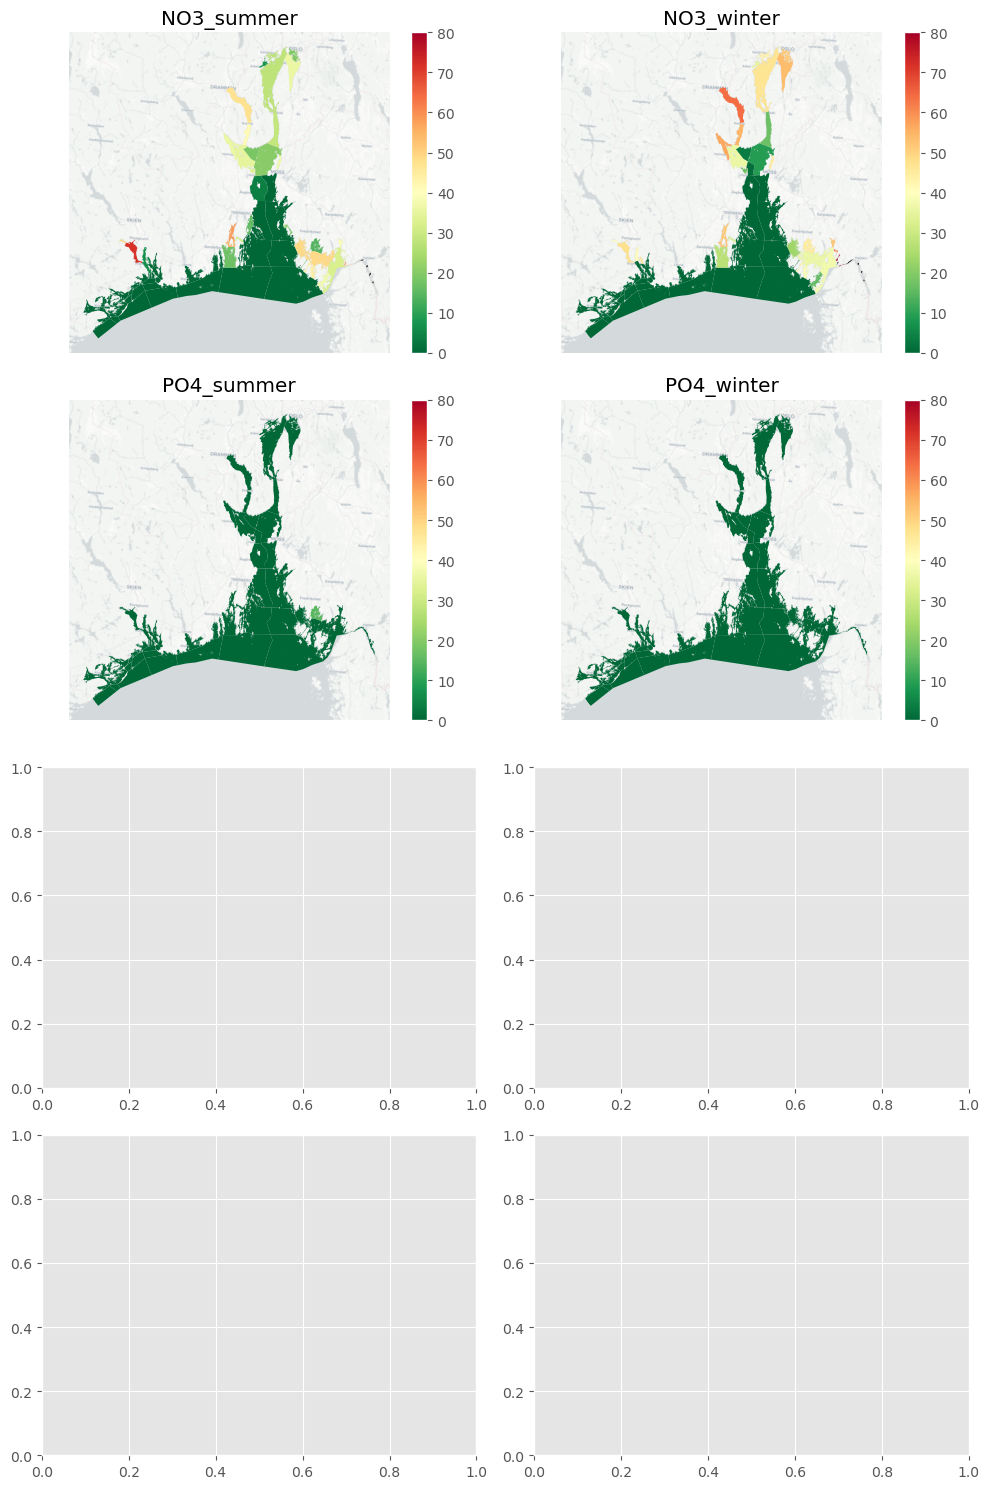

In [9]:
# Read waterbody spatial data
fgdb_path = (
    r"/home/jovyan/shared/common/01_datasets/spatial/vector/Vannforekomster_2025.gdb"
)
wb_gdf = gpd.read_file(fgdb_path, layer="VannforekomstKyst")[
    ["identifikasjon_lokalId", "geometry"]
]
wb_gdf.columns = ["wb_id", "geometry"]

# Setup plot
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 15))
axes = axes.flatten()

# Define colour scheme based on Vann-Nett colours
# colors = ["#9BBECB", "#6FB22C", "#FFF6A6", "#FACB66", "#E63D5C"]
# custom_cmap = LinearSegmentedColormap.from_list("BlGnYlOrRd", colors)
custom_cmap = "RdYlGn_r"

# One map per parameter
for idx, par in enumerate(par_dict.keys()):
    par_df = res_df.query("par == @par").copy()
    par_gdf = wb_gdf.merge(par_df, how="inner", on="wb_id")
    par_gdf["avlast_target_pct"] = par_gdf["avlast_target_pct"].abs()
    par_gdf.plot(
        ax=axes[idx],
        column="avlast_target_pct",
        legend=True,
        vmin=0,
        vmax=80,
        cmap=custom_cmap,
        missing_kwds={
            "color": "#D9D9D9",
            "hatch": "///",
            "label": "<GES under 'pristine' scenario",
        },
    )
    cx.add_basemap(
        axes[idx],
        crs=par_gdf.crs.to_string(),
        source=cx.providers.CartoDB.Positron,
        attribution=False,
    )
    axes[idx].axis("off")
    axes[idx].set_title(par)
plt.tight_layout()

# Save
plt.savefig(
    r"../plots/avlastningsbehov_rel_whole_oslofjord.png", dpi=200, bbox_inches="tight"
)

## 6. Plots per waterbody

Showing the change in EQR for each scenario, and the interpolated avlastningsbehov.

In [10]:
par = "NO3_summer"

for wb_id in wb_ids:
    wb_par_df = of_df.query("(Vannforeko == @wb_id) and (Indikator == @par)").copy()
    assert len(wb_par_df) == 4
    wb_par_df = wb_par_df.set_index("scenario")

    # Get class bounds
    class_bnds = [0, 0.2, 0.4, 0.6, 0.8, 1]
    class_colours = ["#E63D5C", "#FACB66", "#FFF6A6", "#6FB22C", "#9BBECB"]

    # Skip if baseline status is already good or better
    base_status = wb_par_df.loc["baseline", "Status"]
    if base_status not in ["Good", "High"]:
        # Get model concs
        base_conc = wb_par_df.loc["baseline", "EQR"]
        sca_conc = wb_par_df.loc["Scenario A", "EQR"]
        scb_conc = wb_par_df.loc["Scenario B", "EQR"]
        if use_of800_pristine_concs:
            pris_conc = wb_par_df.loc["Pristine", "EQR"]
        else:
            pris_conc = 1
        mod_conc = [base_conc, sca_conc, scb_conc, pris_conc]

        # Get WB info
        wb_vassom = int(wb_info_df.query("waterbody_id == @wb_id").iloc[0]["vassom"])
        wb_name = of_df.query("Vannforeko == @wb_id").iloc[0]["Vannfore_1"]

        # Get avlastningsbehov
        avlast_pct = np.abs(
            res_df.query("(wb_id == @wb_id)	and (par == @par)").iloc[0][
                "avlast_target_pct"
            ]
        )

        if wb_vassom > 17:
            # Skip WBs outside of Oslofjord
            pass
        else:
            fig, axes = plt.subplots(figsize=(10, 6))

            # Get percentage changes for scenarios based on whole OF
            teo_par = par_dict[par]
            teo_base = teo_df.query(
                "(Parameter	== @teo_par) and (Scenario == 'Baseline')"
            ).iloc[0]["Verdi (tonn)"]
            teo_sca = teo_df.query(
                "(Parameter	== @teo_par) and (Scenario == 'Scenario_A')"
            ).iloc[0]["Verdi (tonn)"]
            teo_scb = teo_df.query(
                "(Parameter	== @teo_par) and (Scenario == 'Scenario_B')"
            ).iloc[0]["Verdi (tonn)"]
            teo_pri = teo_df.query(
                "(Parameter	== @teo_par) and (Scenario == 'Pristine')"
            ).iloc[0]["Verdi (tonn)"]
            of_base_pct = 0
            of_sca_pct = 100 * (teo_base - teo_sca) / teo_base
            of_scb_pct = 100 * (teo_base - teo_scb) / teo_base
            of_pri_pct = 100 * (teo_base - teo_pri) / teo_base
            of_pct = [of_base_pct, of_sca_pct, of_scb_pct, of_pri_pct]

            # Plot thresholds
            for i in range(len(class_colours)):
                lower_bound = class_bnds[i]
                if i < len(class_bnds) - 1:
                    upper_bound = class_bnds[i + 1]
                    axes.axhspan(
                        lower_bound,
                        upper_bound,
                        facecolor=class_colours[i],
                        alpha=0.5,
                    )

            # Plot whole OF
            axes.plot(
                of_pct,
                mod_conc,
                linestyle="--",
                color="black",
                marker="o",
                markerfacecolor="red",
                markeredgecolor="black",
            )
            axes.plot(
                avlast_pct,
                0.6,
                marker="^",
                markerfacecolor="yellow",
                markeredgecolor="black",
            )
            scens = ["Baseline", "Scenario A", "Scenario B", "Scenario N"]
            for x, y, label in zip(of_pct, mod_conc, scens):
                axes.text(x + 0.1, y - 0.1, label, ha="center", va="bottom")
            axes.set_xlabel("Scenariereduksjon fra baseline (for hele Oslofjorden) [%]")
            # axes.set_ylabel(f"EQR for {par}")
            axes.set_ylabel(f"EQR for Nitrat (sommer) [-] ")
            plt.suptitle(
                f"{wb_id} ({wb_name})\nVassdragsområde {wb_vassom:03d}", fontsize=20
            )
            plt.tight_layout()

            # Save
            png_path = f"../plots/wb_plots/{wb_id.replace(' ', '-')}.png"
            plt.savefig(png_path, dpi=200, bbox_inches="tight")

            plt.close()

## 7. Categorical maps

Avlastningsbehov in 15 % interval classes.

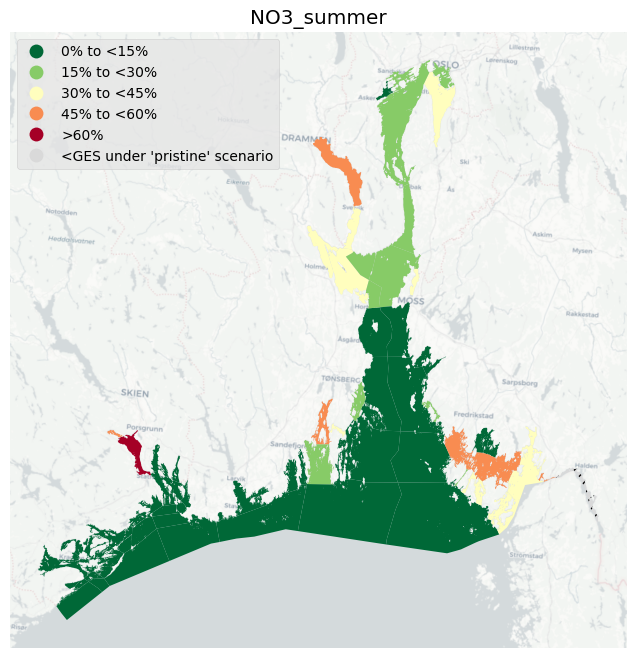

In [11]:
no3_sum_df = res_df.query("par == 'NO3_summer'").copy()

bins = [0, 15, 30, 45, 60, float("inf")]
labels = [
    "0% to <15%",
    "15% to <30%",
    "30% to <45%",
    "45% to <60%",
    ">60%",
]

no3_sum_df["avlast_target_pct"] = no3_sum_df["avlast_target_pct"].abs()
no3_sum_df["avlast_target_category"] = pd.cut(
    no3_sum_df["avlast_target_pct"], bins=bins, labels=labels, right=False
)

par_gdf = wb_gdf.merge(no3_sum_df, how="inner", on="wb_id")
ax = par_gdf.plot(
    column="avlast_target_category",
    legend=True,
    missing_kwds={
        "color": "#D9D9D9",
        "hatch": "///",
        "label": "<GES under 'pristine' scenario",
    },
    legend_kwds={"loc": "upper left"},
    figsize=(8, 8),
    cmap=custom_cmap,
)
cx.add_basemap(
    ax,
    crs=par_gdf.crs.to_string(),
    source=cx.providers.CartoDB.Positron,
    attribution=False,
)
ax.axis("off")
ax.set_title("NO3_summer")

png_path = r"../plots/no3_summer_avlast_categorical.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight")

## 8. Explore pristine riverine concentrations

In [12]:
par = "totn"

csv_path = r"/home/jovyan/shared/common/oslofjord_modelling/phase3_scenarios/teotil3_oslomod_results_2017-2019.csv"
vassoms = [f"{i:03d}." for i in range(1, 18)]
df = pd.read_csv(csv_path).query("(scenario == 'Baseline') and (regine in @vassoms)")
back_srcs = ["agriculture-background", "lake", "upland", "wood"]
nat_cols = [f"accum_{src}_{par}_kg" for src in back_srcs]
df["nat_kg"] = df[nat_cols].sum(axis="columns")
cols = ["regine", "year", "accum_q_m3/s", "nat_kg"]
df = df[cols].groupby("regine").sum()
df["conc"] = 1e9 * df["nat_kg"] / (df["accum_q_m3/s"] * 60 * 60 * 24 * 365.25 * 1000)
df.sort_values("conc", ascending=True)

,year,accum_q_m3/s,nat_kg,conc
regine,,,,
016.,6054,983.272526,4.601905e+06,148.306365
012.,6054,1093.230334,6.077088e+06,176.148892
002.,6054,2335.299296,1.610643e+07,218.550937
015.,6054,398.220637,2.834270e+06,225.534741
006.,6054,24.658945,1.767713e+05,227.160765
017.,6054,138.315757,1.151572e+06,263.824733
001.,6054,117.872564,9.848357e+05,264.756790
007.,6054,15.498658,1.430562e+05,292.488444
008.,6054,15.296402,1.504658e+05,311.705504


## 9. Cumulative curve showing number of waterbodies at GES for different avlastningsbehov

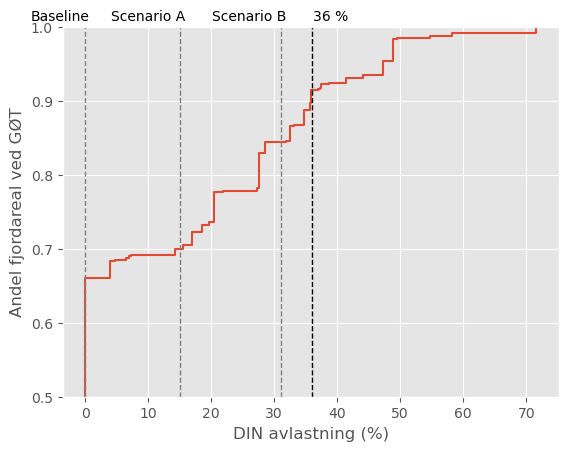

In [13]:
par = "NO3_summer"

cum_df = res_df.query("par== @par").copy()
cum_gdf = wb_gdf.merge(cum_df, how="inner", on="wb_id")
cum_gdf["area_km2"] = cum_gdf.to_crs({"proj": "cea"}).geometry.area / 1e6
cum_gdf["avlast_target_pct"] = cum_gdf["avlast_target_pct"].abs()
ax = sn.ecdfplot(data=cum_gdf, x="avlast_target_pct", weights="area_km2")
plt.xlabel("DIN avlastning (%)")
plt.ylim(ymin=0.5)
plt.ylabel("Andel fjordareal ved GØT")

# Add labels at top (x in data coords, y in axes coords)
labels = {0: ("Baseline", 4), 15: ("Scenario A", 5), 31: ("Scenario B", 5)}
for x, (label, offset) in labels.items():
    ax.axvline(x=x, color="grey", linestyle="--", linewidth=1)
    ax.text(
        x - offset,
        1.01,
        label,
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=0,
    )
ax.axvline(x=36, color="black", linestyle="--", linewidth=1)
ax.text(
    36 + 3,
    1.01,
    "36 %",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="bottom",
    fontsize=10,
    rotation=0,
)

# Save
png_path = f"../plots/{par.lower()}_avlast_vs_fjord_area_at_ges.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight")

## 9. Number of waterbodies at each status class for each scenario

In [14]:
par_grp_dict = {
    "N03": [
        "NO3_summer",
        "NO3_winter",
    ],
    "N-other": [
        "NH4-N sommer",
        "NH4-N vinter",
        "TN_summer",
        "TN_winter",
    ],
    "P": ["PO4_summer", "PO4_winter", "TP_summer", "TP_winter"],
    # "Chla_Secc": ["Klfa 90pct", "Klfa sommer", "Siktdyp"], # 'Kfla_sommer' is only included in the 2023 revisions
    "Chla_Secc": ["Klfa 90pct", "Siktdyp"],  # For the official 2018 elements
    "MSMDI": ["MSMDI"],
    "BO": ["Oksygen"],
}

# Get model data
status_df = of_df.copy()

# Assign WBs to Inner and Outer fjord
status_df = pd.merge(
    status_df,
    wb_info_df[["waterbody_id", "vassom"]],
    how="left",
    left_on="Vannforeko",
    right_on="waterbody_id",
)
status_df["vassom"] = status_df["vassom"].astype(int)
status_df = status_df.query("vassom <= 17")
conditions = [
    (status_df["vassom"].between(5, 9, inclusive="both")),  # Indre Oslofjord
    (
        (status_df["vassom"].between(1, 4, inclusive="both"))
        | (status_df["vassom"].between(10, 17, inclusive="both"))
    ),  # Ytre Oslofjord
]
choices = ["Indre Oslofjord", "Ytre Oslofjord"]
status_df["Område"] = np.select(conditions, choices, default=None)
status_df.dropna(subset="Område")

#  Add a copy for the whole OF
whole_df = status_df.copy()
whole_df["Område"] = "Hele Oslofjord"
status_df = pd.concat([status_df, whole_df], axis="rows")

# Tidy names
status_df["scenario"] = status_df["scenario"].replace(
    {"baseline": "Baseline", "Pristine": "Scenario N"}
)
status_df["Status"] = status_df["Status"].replace(
    {
        "High": "Svært god",
        "Good": "God",
        "Mod": "Moderat",
        "Poor": "Dårlig",
        "Bad": "Svært dårlig",
    }
)
ind_names_dict = {
    "NO3_summer": "NOx (sommer)",
    "NO3_winter": "NOx (vinter)",
    "NH4-N sommer": "NH4 (sommer)",
    "NH4-N vinter": "NH4 (vinter)",
    "TN_summer": "TotN (sommer)",
    "TN_winter": "TotN (vinter)",
    "PO4_summer": "PO4 (sommer)",
    "PO4_winter": "PO4 (vinter)",
    "TP_summer": "TotP (sommer)",
    "TP_winter": "TotP (vinter)",
    "Klfa 90pct": "Klfa 90pct",
    "Siktdyp": "Siktdyp",
    "Oksygen": "Oksygen",
    "MSMDI": "MSMDI",
}

hue_order = ["Svært dårlig", "Dårlig", "Moderat", "God", "Svært god"]
class_colours = ["#E63D5C", "#FACB66", "#FFF6A6", "#6FB22C", "#9BBECB"]
palette = dict(zip(hue_order, class_colours))
for grp, par_list in par_grp_dict.items():
    grp_df = status_df.query("Indikator in @par_list").copy()
    grp_df["Indikator"] = grp_df["Indikator"].replace(ind_names_dict)
    grp_df["Count"] = 1
    grp_df = (
        grp_df.groupby(["scenario", "Indikator", "Område", "Status"])
        .count()["Count"]
        .reset_index()
    )
    grp_df.columns = [
        "Scenario",
        "Indikator",
        "Område",
        "Tilstand",
        "Antall vannforekomster",
    ]

    # Plot
    g = sn.catplot(
        data=grp_df,
        x="Scenario",
        y="Antall vannforekomster",
        hue="Tilstand",
        row="Indikator",
        col="Område",
        kind="bar",
        hue_order=["Svært dårlig", "Dårlig", "Moderat", "God", "Svært god"],
        col_order=["Indre Oslofjord", "Ytre Oslofjord", "Hele Oslofjord"],
        row_order=[ind_names_dict[i] for i in par_list],
        palette=palette,
        legend=False,
        sharex=False,
        sharey="row",
        height=3.5,
        aspect=1.5,
    )
    # g.set_titles(template="{col_name}", size=16)
    g.set_xlabels(size=16)
    g.set_ylabels(size=16)
    for ax in g.axes.flat:
        ax.tick_params(axis="both", labelsize=14)

    # Label bars
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(
                container,
                label_type="edge",
                padding=2,
                fmt="%.0f",
                fontsize=10,
                fontweight="bold",
            )

    # Add legend at bottom
    offset_pts = -30
    bbox_transform = g.fig.transFigure + mtransforms.ScaledTranslation(
        0, (offset_pts / 72.0), g.fig.dpi_scale_trans
    )
    handles = [
        Patch(facecolor=palette[label], edgecolor="none", label=label)
        for label in hue_order
    ]
    leg = g.fig.legend(
        handles=handles,
        labels=hue_order,
        loc="lower center",
        ncol=5,
        frameon=False,
        fontsize=16,
        title=None,
        bbox_to_anchor=(0.5, 0.0),  # anchor on bottom-center of the figure
        bbox_transform=bbox_transform,  # add an absolute (point) offset
    )
    for ax in g.axes[-1, :]:
        ax.set_xlabel(None)
    plt.tight_layout()

    # Save
    png_path = f"../plots/n_wbs_by_status_{grp.lower()}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close()

In [15]:
100 * len(cum_gdf.query("avlast_target_pct > 36")) / len(cum_gdf)

15.384615384615385